In [14]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.container { font-size:18px !important; }</style>"))

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from scipy.ndimage import zoom

C:\Users\HP\AppData\Local\Temp\ipykernel_14732\2323087245.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [15]:
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

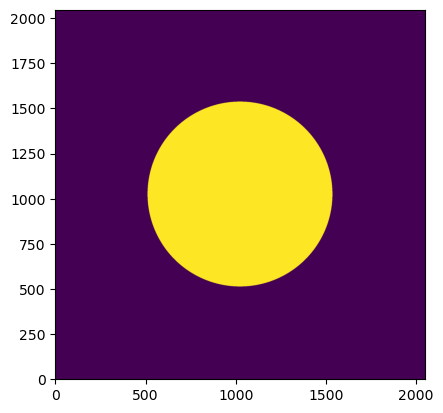

In [16]:
#make the aperture:
N = 2048 #number of points
a = 8.0 #total size of the grid, in meters
aperture = np.zeros([N,N]) #array containing the aperture (1 will be where light can enter, zero where it cannot)

x = np.linspace(-a/2.0,a/2.0,N) #x grid
y = np.linspace(-a/2.0,a/2.0,N) #y grid
R = 2.0 #radius of our telescope, this is one m, like SST :)


#make circular aperture
for i in range(0,N):
    for j in range(0,N):
        if ((x[i]**2.0 + y[j]**2.0)**0.5 <= R):
            aperture[i,j] = 1.0

plt.imshow(np.real(aperture),origin='lower') #plot the aprerture

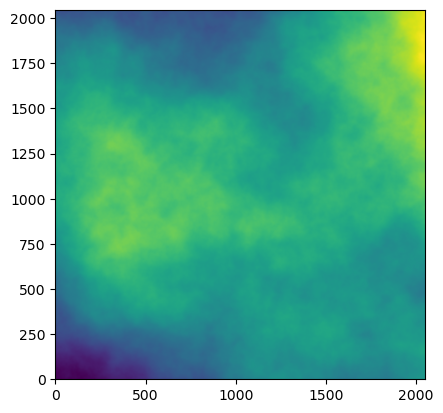

In [83]:
phase = fits.open("phase.fits")[0].data
plt.imshow(phase, origin='lower')
#aperture = aperture *np.exp(-1.j*phase)
#plt.imshow(np.real(aperture),origin='lower')

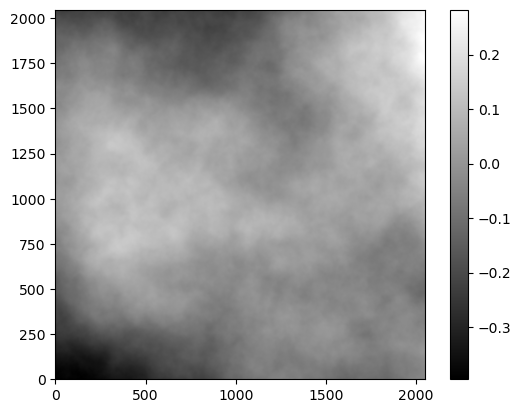

In [85]:
#add phase information to the aperture
phase *= np.pi/180.0
plt.imshow(phase,origin='lower',cmap='gray')
plt.colorbar()

#aqui esta en radianes 


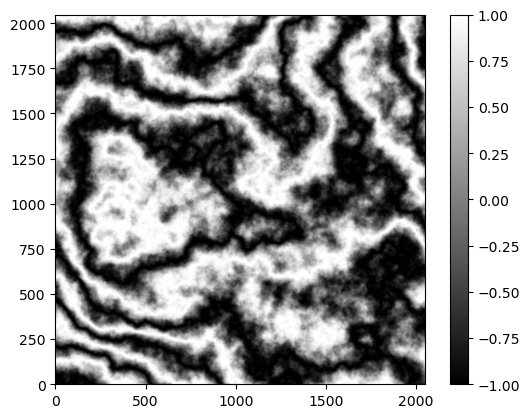

In [33]:
plt.imshow(np.real(np.exp(1.j*phase)),origin='lower',cmap='gray')
plt.colorbar()

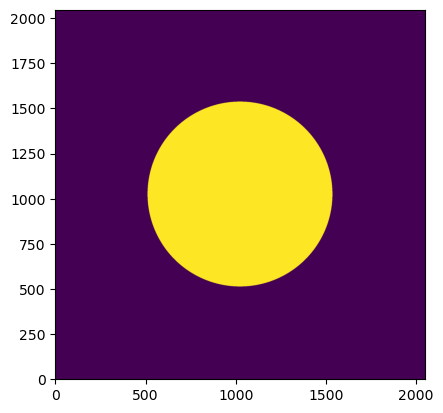

In [35]:
#aperture = aperture * np.exp(1.j*phase)
plt.imshow(np.real(aperture),origin='lower') #plot the aprerture

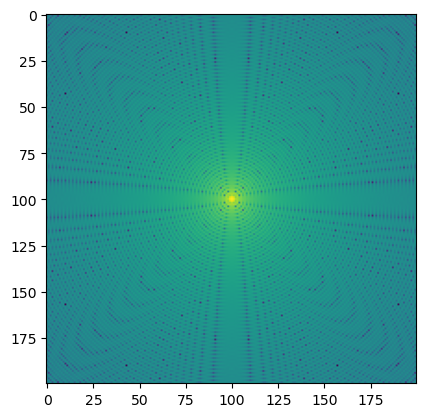

In [37]:
# Now, from the (complex) aperture, we calculate the FFT: Se crea una nueva apertura FFT 
#que es la forma cuadrada de la transformada de Fourier bidimensional de mi función  

aperture_fft = np.fft.fft2(aperture)
PSF = np.abs(aperture_fft)
PSF = PSF**2.0

# we need to rearange this:
PSF = np.fft.fftshift(PSF,axes=(0,1))

#we are only going to be interested in the innermost part of the PSF
N_small = 200
PSF = PSF[N//2-N_small//2:N//2+N_small//2,N//2-N_small//2:N//2+N_small//2]
# we plot psf in the log scale
plt.imshow(np.log10(PSF[:,:]))

In [104]:
PSF.shape

(200, 200)

(0.0, 0.05)

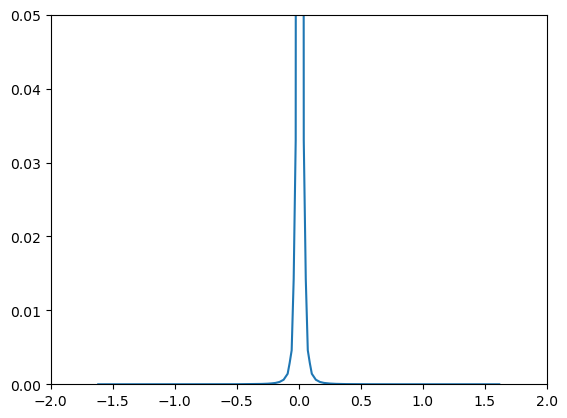

In [39]:
# At the moment, our x (and y) scales for the PSF are in pixels, so to speak. Realistically they should be in wave numbers
# Then we need to transform these wavenumbers into angles. We don't have time to clarify this but transformation is done in
# the following way:
x_step = a / N #step of the original image
#Frecuencias espaciales que se transformarán mediante la tranformada de Fourier
xf = np.linspace(-1.0/(2.0*x_step),1.0/(2.0*x_step), N) #space of spatial frequencies
llambda = 630E-9 # wavelength we are observing at
theta = xf*llambda * 206265 #transform the spatial frequencies to angles
theta = theta[N//2-N_small//2:N//2+N_small//2] #select the appropriate part for the narrowed down PSF
norm = np.amax(PSF) # we want to normalize the psf with respect to maximum first:
PSF /= norm
plt.plot(theta,PSF[100]) #plot the middle raw
plt.xlim([-2,2])
plt.ylim([0,0.05])

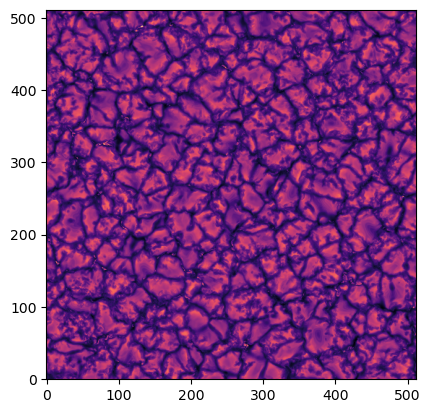

In [41]:
# load the image from file
image = fits.open("synth_sun.fits")[0].data
plt.imshow(image,origin='lower',cmap='magma')

-1.617004743722521 1.617004743722521


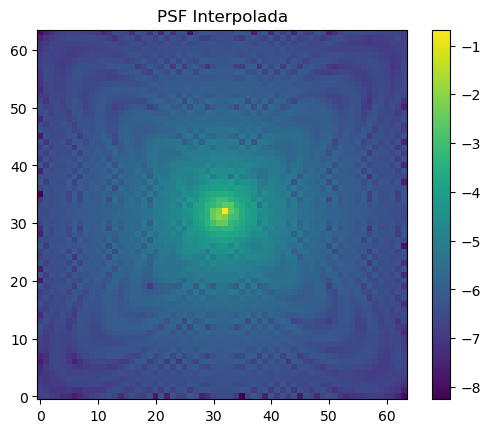

In [71]:
# theta = array de valores originales
# PSF = matriz 2D con la función PSF
print(theta.min(), theta.max())

interp = RegularGridInterpolator((theta, theta), PSF)

# Crear la grilla interpolada
grid_interpolate = np.linspace(theta.min(), theta.max(), 64)
X_new, Y_new = np.meshgrid(grid_interpolate, grid_interpolate)
points = np.array([X_new.ravel(), Y_new.ravel()]).T
psf_interpolated = interp(points).reshape(X_new.shape)

# Preparar puntos para evaluación
points = np.array([X_new.ravel(), Y_new.ravel()]).T

# Interpolar
psf_interpolated = interp(points).reshape(X_new.shape)


# Visualizar
plt.imshow(np.log10(psf_interpolated), origin="lower")
plt.colorbar()
plt.title("PSF Interpolada")
plt.show()


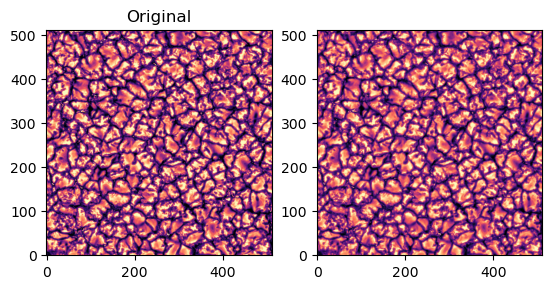

In [73]:
# now finally, convolve
from scipy.signal import convolve2d

# we have to normalize again so that the surface of the psf is one
psf_interpolated /= np.sum(psf_interpolated)

image_smeared = convolve2d(image,psf_interpolated,mode='same',boundary='symm')

mean = np.mean(image)
image /= mean
image_smeared /=mean

##convolution messes up with our edges, so we can get rid of them:
#image = image[50:-50,50:-50]
#image_smeared = image_smeared[32:-32,32:-32]

plt.subplot(121)
plt.imshow(image,vmin=0.7,vmax=1.3,origin='lower',cmap='magma')
plt.title('Original')
plt.subplot(122)
plt.imshow(image_smeared,vmin=0.7,vmax=1.3,origin='lower',cmap='magma')

In [75]:
print(np.std(image))
print(np.std(image_smeared))

0.1712641602824972
0.15786697151208104
